In [206]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [207]:
import seaborn as sns

df = sns.load_dataset("titanic")
x= df.drop(columns=["survived", "alive"])  # Drop target columns
y = df["survived"]  # Your binary target
x

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,False
1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,True
3,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,False
4,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,True
887,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,True
888,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,False
889,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,True


In [208]:
x.info()
x['alone']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   pclass       891 non-null    int64   
 1   sex          891 non-null    object  
 2   age          714 non-null    float64 
 3   sibsp        891 non-null    int64   
 4   parch        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   embarked     889 non-null    object  
 7   class        891 non-null    category
 8   who          891 non-null    object  
 9   adult_male   891 non-null    bool    
 10  deck         203 non-null    category
 11  embark_town  889 non-null    object  
 12  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(3), object(4)
memory usage: 66.7+ KB


0      False
1      False
2       True
3      False
4       True
       ...  
886     True
887     True
888    False
889     True
890     True
Name: alone, Length: 891, dtype: bool

In [209]:
x['parch']
x['pclass']
# x['class']
x['deck']

0      NaN
1        C
2      NaN
3        C
4      NaN
      ... 
886    NaN
887      B
888    NaN
889      C
890    NaN
Name: deck, Length: 891, dtype: category
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']

In [210]:
x.drop(columns=['sibsp','class','adult_male','deck','alone','embark_town','who'],inplace=True)


In [211]:
x['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [212]:
x.head(5)

,pclass,sex,age,parch,fare,embarked
0,3,male,22.0,0,7.2500,S
1,1,female,38.0,0,71.2833,C
2,3,female,26.0,0,7.9250,S
3,1,female,35.0,0,53.1000,S
4,3,male,35.0,0,8.0500,S


In [213]:

x['age'].fillna(x['age'].mean(),inplace=True)

/tmp/ipykernel_58/86115857.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x['age'].fillna(x['age'].mean(),inplace=True)


In [214]:
x['age'].isnull().sum
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

trf=ColumnTransformer(transformers=[('trf1',OneHotEncoder(),['sex','embarked'])],remainder='passthrough')
x_trf=trf.fit_transform(x)
x_trf=pd.DataFrame(x_trf,columns=trf.get_feature_names_out())


In [215]:
x_trf

,trf1__sex_female,trf1__sex_male,trf1__embarked_C,trf1__embarked_Q,trf1__embarked_S,trf1__embarked_nan,remainder__pclass,remainder__age,remainder__parch,remainder__fare
0,0.0,1.0,0.0,0.0,1.0,0.0,3.0,22.000000,0.0,7.2500
1,1.0,0.0,1.0,0.0,0.0,0.0,1.0,38.000000,0.0,71.2833
2,1.0,0.0,0.0,0.0,1.0,0.0,3.0,26.000000,0.0,7.9250
3,1.0,0.0,0.0,0.0,1.0,0.0,1.0,35.000000,0.0,53.1000
4,0.0,1.0,0.0,0.0,1.0,0.0,3.0,35.000000,0.0,8.0500
...,...,...,...,...,...,...,...,...,...,...
886,0.0,1.0,0.0,0.0,1.0,0.0,2.0,27.000000,0.0,13.0000
887,1.0,0.0,0.0,0.0,1.0,0.0,1.0,19.000000,0.0,30.0000
888,1.0,0.0,0.0,0.0,1.0,0.0,3.0,29.699118,2.0,23.4500
889,0.0,1.0,1.0,0.0,0.0,0.0,1.0,26.000000,0.0,30.0000


In [216]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_trf,y)

In [217]:
x_train.shape

(668, 10)

In [218]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential
model=Sequential()
model.add(Dense(32,activation='relu',input_dim=10))
model.add(Dense(16,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(4,activation='relu'))

model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])
from tensorflow.keras.callbacks import EarlyStopping

# patience=10 ka matlab hai agar 10 epochs tak val_loss nahi sudhra, toh brake lagao
# restore_best_weights=True ka matlab hai jab training rukegi, toh woh best epoch (e.g. Epoch 32) ke weights ko final automatically load kar dega
early_stop = EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)
history=model.fit(x_train,y_train,epochs=100,validation_split=0.2,callbacks=[early_stop])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5468 - loss: 0.9751 - val_accuracy: 0.6343 - val_loss: 0.6967
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6067 - loss: 0.7238 - val_accuracy: 0.6418 - val_loss: 0.6216
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6180 - loss: 0.6412 - val_accuracy: 0.5896 - val_loss: 0.6011
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6667 - loss: 0.6199 - val_accuracy: 0.6418 - val_loss: 0.5958
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6835 - loss: 0.6159 - val_accuracy: 0.6269 - val_loss: 0.5958
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6966 - loss: 0.6134 - val_accuracy: 0.6493 - val_loss: 0.5906
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6948 - loss: 0.6115 - val_accuracy: 0.6567 - val_loss: 0.5879
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6966 - loss: 0.6094 - val_accuracy: 0.6567 - 

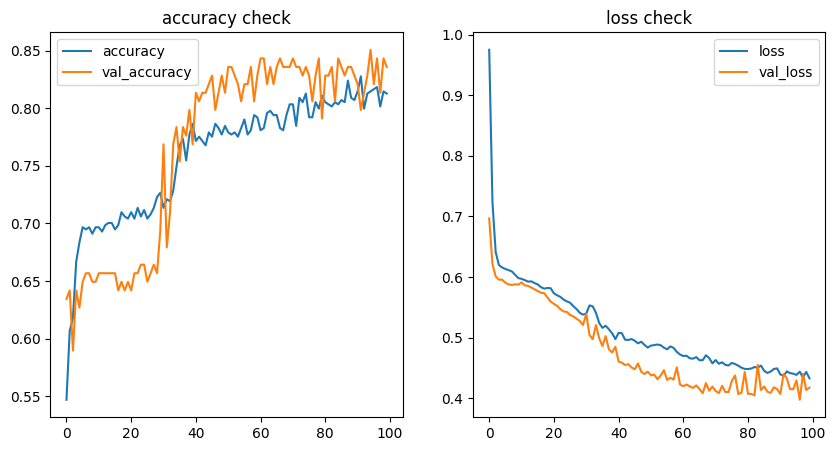

In [219]:
import matplotlib.pyplot as plt 
fig, (ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
ax1.plot(history.history['accuracy'],label='accuracy')
ax1.plot(history.history['val_accuracy'],label='val_accuracy')
ax1.set_title("accuracy check")
ax2.plot(history.history['loss'],label='loss')
ax2.plot(history.history['val_loss'],label='val_loss')
ax2.set_title("loss check")
ax1.legend()
ax2.legend()

In [220]:
y_pred=model.predict(x_test)
y_pred=np.where(y_pred<0.5,0,1)
y_pred

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


array([[0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
    

In [221]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

0.8251121076233184

In [223]:
print( classifcation_report(y_pred))

NameError: name 'classifcation_report' is not defined